In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [ ]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'


In [ ]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Cameroon/data'

In [57]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [3]:
GID2_NAME = 'Benoue'
YEAR = 'test'

In [58]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [4]:
df = pd.read_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_GID3_{YEAR}_filled.csv', encoding=enc)

In [5]:
df.head()

,GID_2,GID2_NAME,GID_3,GID3_NAME,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-01,2025,1,2025-01-30,9.659135,13.274854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,9.659135,13.274854,15619.0,14528.0,2025-01-01,9.650044,13.250061,2024-12-31,2025-01-31,0.0
1,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-02,2025,1,2025-01-02,9.659135,13.274854,0.181451,-0.194437,-0.303886,0.194437,0.187432,-0.170033,-0.312673,0.170033,0.012662,0.018063,0.011546,0.018063,2025-01-02,9.659135,13.274854,15619.0,14501.0,2025-01-02,9.650044,13.250061,2025-01-01,2025-01-01,0.0
2,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-03,2025,1,2025-01-02,9.659135,13.274854,0.181451,-0.194437,-0.303886,0.194437,0.187432,-0.170033,-0.312673,0.170033,0.012662,0.018063,0.011546,0.018063,2025-01-03,9.659135,13.274854,15496.0,14517.0,2025-01-03,9.650044,13.250061,2025-01-02,2025-01-02,0.0
3,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-04,2025,1,2025-01-04,9.659135,13.274854,0.181451,-0.194437,-0.303886,0.194437,0.187432,-0.170033,-0.312673,0.170033,0.012662,0.018063,0.011546,0.018063,2025-01-04,9.659135,13.274854,15561.0,14636.0,2025-01-04,9.650044,13.250061,2025-01-03,2025-01-03,0.0
4,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-05,2025,1,2025-01-05,9.659135,13.274854,0.177654,-0.217172,-0.304133,0.217172,0.184192,-0.193571,-0.313419,0.193571,0.011996,0.018615,0.010677,0.018615,2025-01-05,9.659135,13.274854,15299.0,14556.0,2025-01-05,9.650044,13.250061,2025-01-04,2025-01-04,0.0


In [6]:
df['dt_placement'] = pd.to_datetime(df['dt_placement'])
df['indices_image_date'] = pd.to_datetime(df['indices_image_date'])
df['lst_image_date'] = pd.to_datetime(df['lst_image_date'])
df['indices_image_date.1'] = pd.to_datetime(df['indices_image_date.1'])
df['dt_placement_minus_1'] = pd.to_datetime(df['dt_placement_minus_1'])
df['dt_placement_minus_1_avail'] = pd.to_datetime(df['dt_placement_minus_1_avail'])

Text(0.5, 1.0, 'Year: 2025')

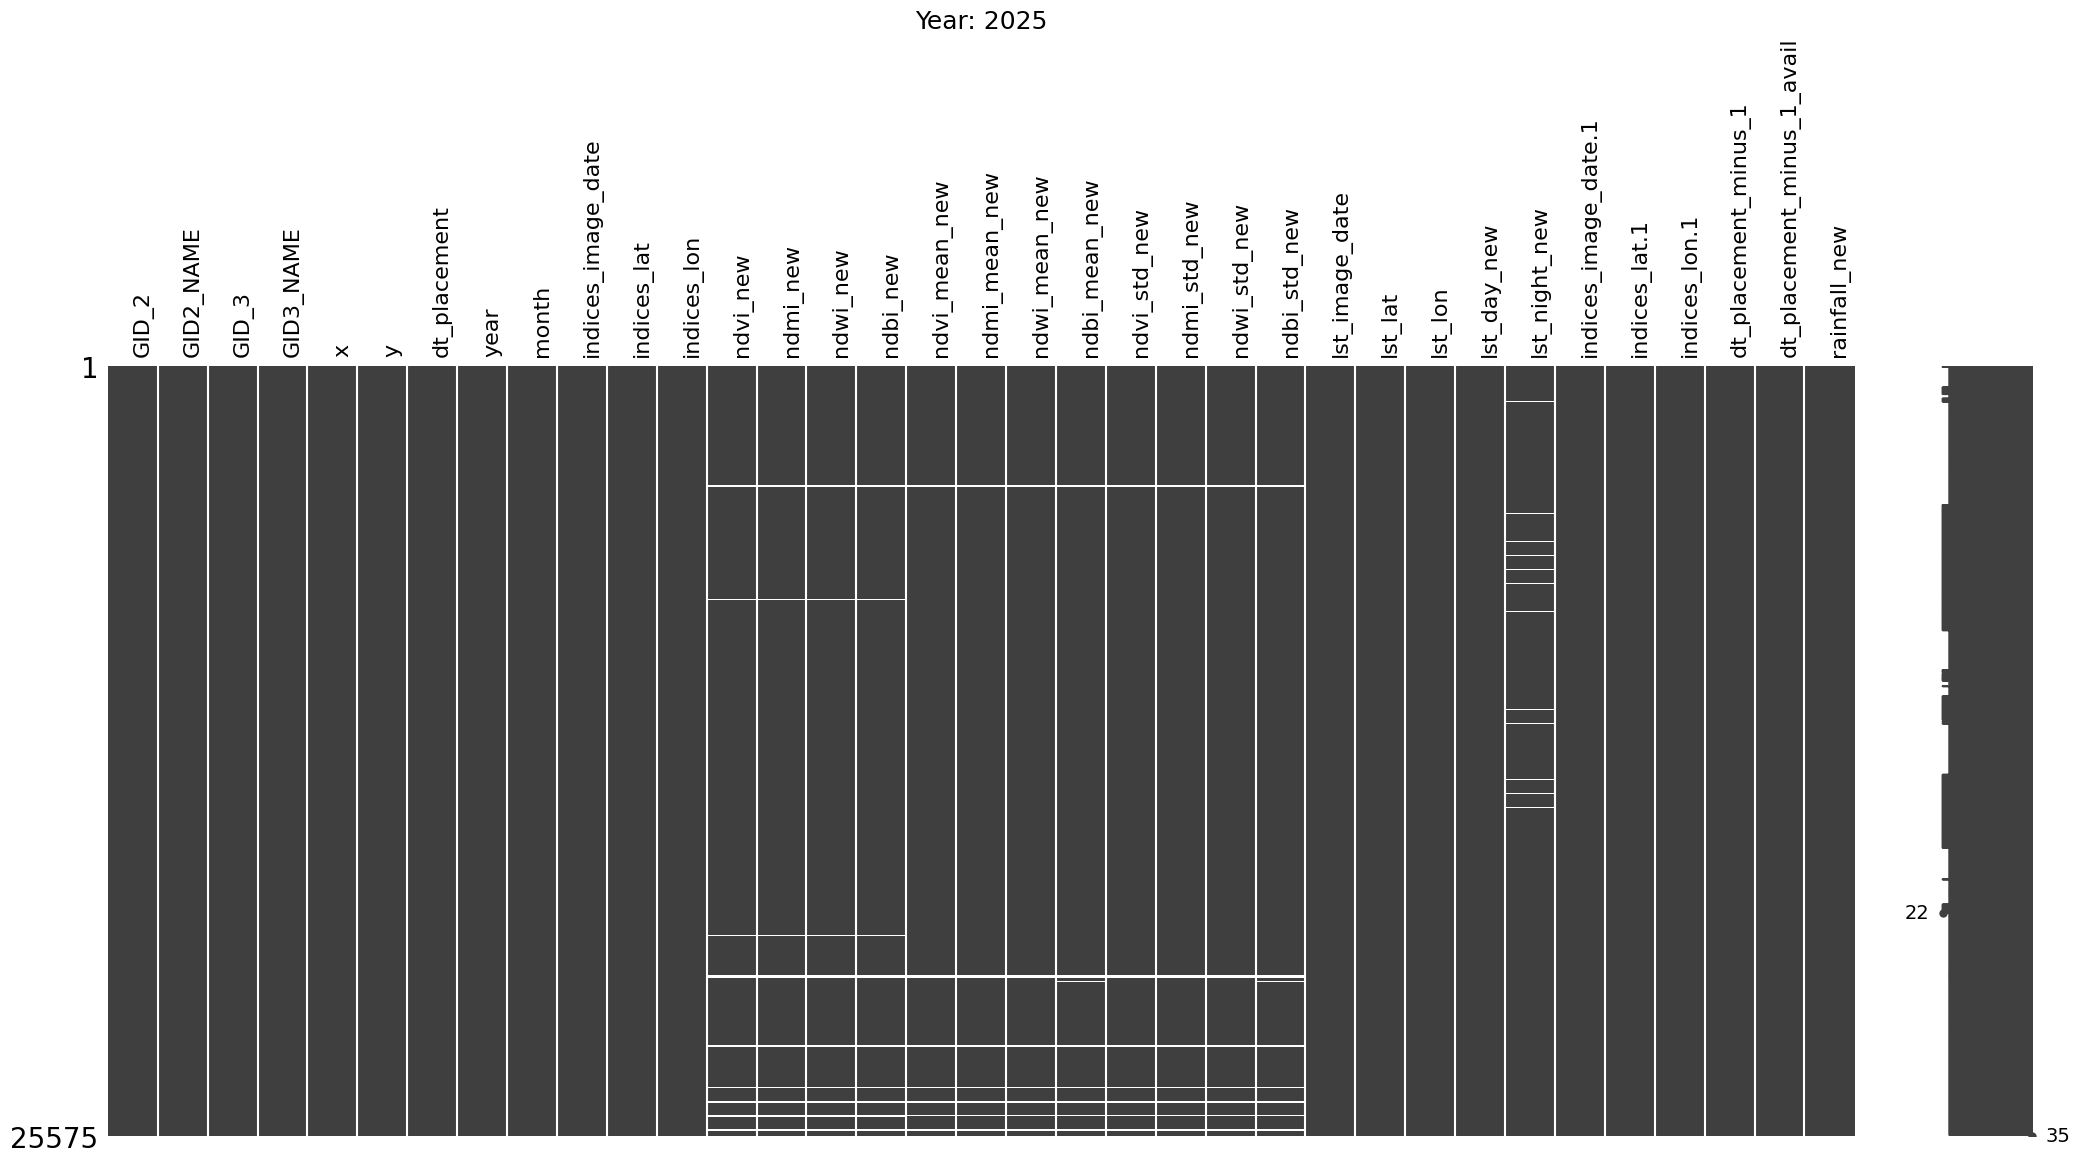

In [7]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [8]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
12,ndvi_new,4.5279
13,ndmi_new,4.5279
14,ndwi_new,4.5279
15,ndbi_new,4.5279
16,ndvi_mean_new,4.1056
17,ndmi_mean_new,4.1056
18,ndwi_mean_new,4.1056
19,ndbi_mean_new,4.1134
20,ndvi_std_new,4.1056
21,ndmi_std_new,4.1056


In [9]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [10]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
10,ndvi,4.5279
11,ndmi,4.5279
12,ndwi,4.5279
13,ndbi,4.5279
14,ndvi_mean,4.1056
15,ndmi_mean,4.1056
16,ndwi_mean,4.1056
17,ndbi_mean,4.1134
18,ndvi_std,4.1056
19,ndmi_std,4.1056


In [11]:
df2 = df.copy()

In [12]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [13]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,ndvi,4.5279
11,ndmi,4.5279
12,ndwi,4.5279
13,ndbi,4.5279
14,ndvi_mean,4.1056
15,ndmi_mean,4.1056
16,ndwi_mean,4.1056
17,ndbi_mean,4.1134
18,ndvi_std,4.1056
19,ndmi_std,4.1056


In [14]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [15]:
df2.reset_index(drop=True, inplace=True)

In [16]:
df2

,GID_2,GID2_NAME,GID_3,GID3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15619.0,14528.0,0.0
1,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-02,2025,1,0.181451,-0.194437,-0.303886,0.194437,0.187432,-0.170033,-0.312673,0.170033,0.012662,0.018063,0.011546,0.018063,15619.0,14501.0,0.0
2,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-03,2025,1,0.181451,-0.194437,-0.303886,0.194437,0.187432,-0.170033,-0.312673,0.170033,0.012662,0.018063,0.011546,0.018063,15496.0,14517.0,0.0
3,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-04,2025,1,0.181451,-0.194437,-0.303886,0.194437,0.187432,-0.170033,-0.312673,0.170033,0.012662,0.018063,0.011546,0.018063,15561.0,14636.0,0.0
4,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737,2025-01-05,2025,1,0.177654,-0.217172,-0.304133,0.217172,0.184192,-0.193571,-0.313419,0.193571,0.011996,0.018615,0.010677,0.018615,15299.0,14556.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25570,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.92331,9.36878,2025-01-27,2025,1,0.180960,-0.134621,-0.318401,0.134621,0.200313,-0.157048,-0.308043,0.157048,0.028210,0.021140,0.017864,0.021140,15158.0,14604.0,0.0
25571,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.92331,9.36878,2025-01-28,2025,1,0.180960,-0.134621,-0.318401,0.134621,0.200313,-0.157048,-0.308043,0.157048,0.028210,0.021140,0.017864,0.021140,15332.0,14486.0,0.0
25572,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.92331,9.36878,2025-01-29,2025,1,0.180960,-0.134621,-0.318401,0.134621,0.200313,-0.157048,-0.308043,0.157048,0.028210,0.021140,0.017864,0.021140,15431.0,14591.0,0.0
25573,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.92331,9.36878,2025-01-30,2025,1,0.180960,-0.134621,-0.318401,0.134621,0.200313,-0.157048,-0.308043,0.157048,0.028210,0.021140,0.017864,0.021140,15321.0,14497.0,0.0


Text(0.5, 1.0, 'Year: 2025')

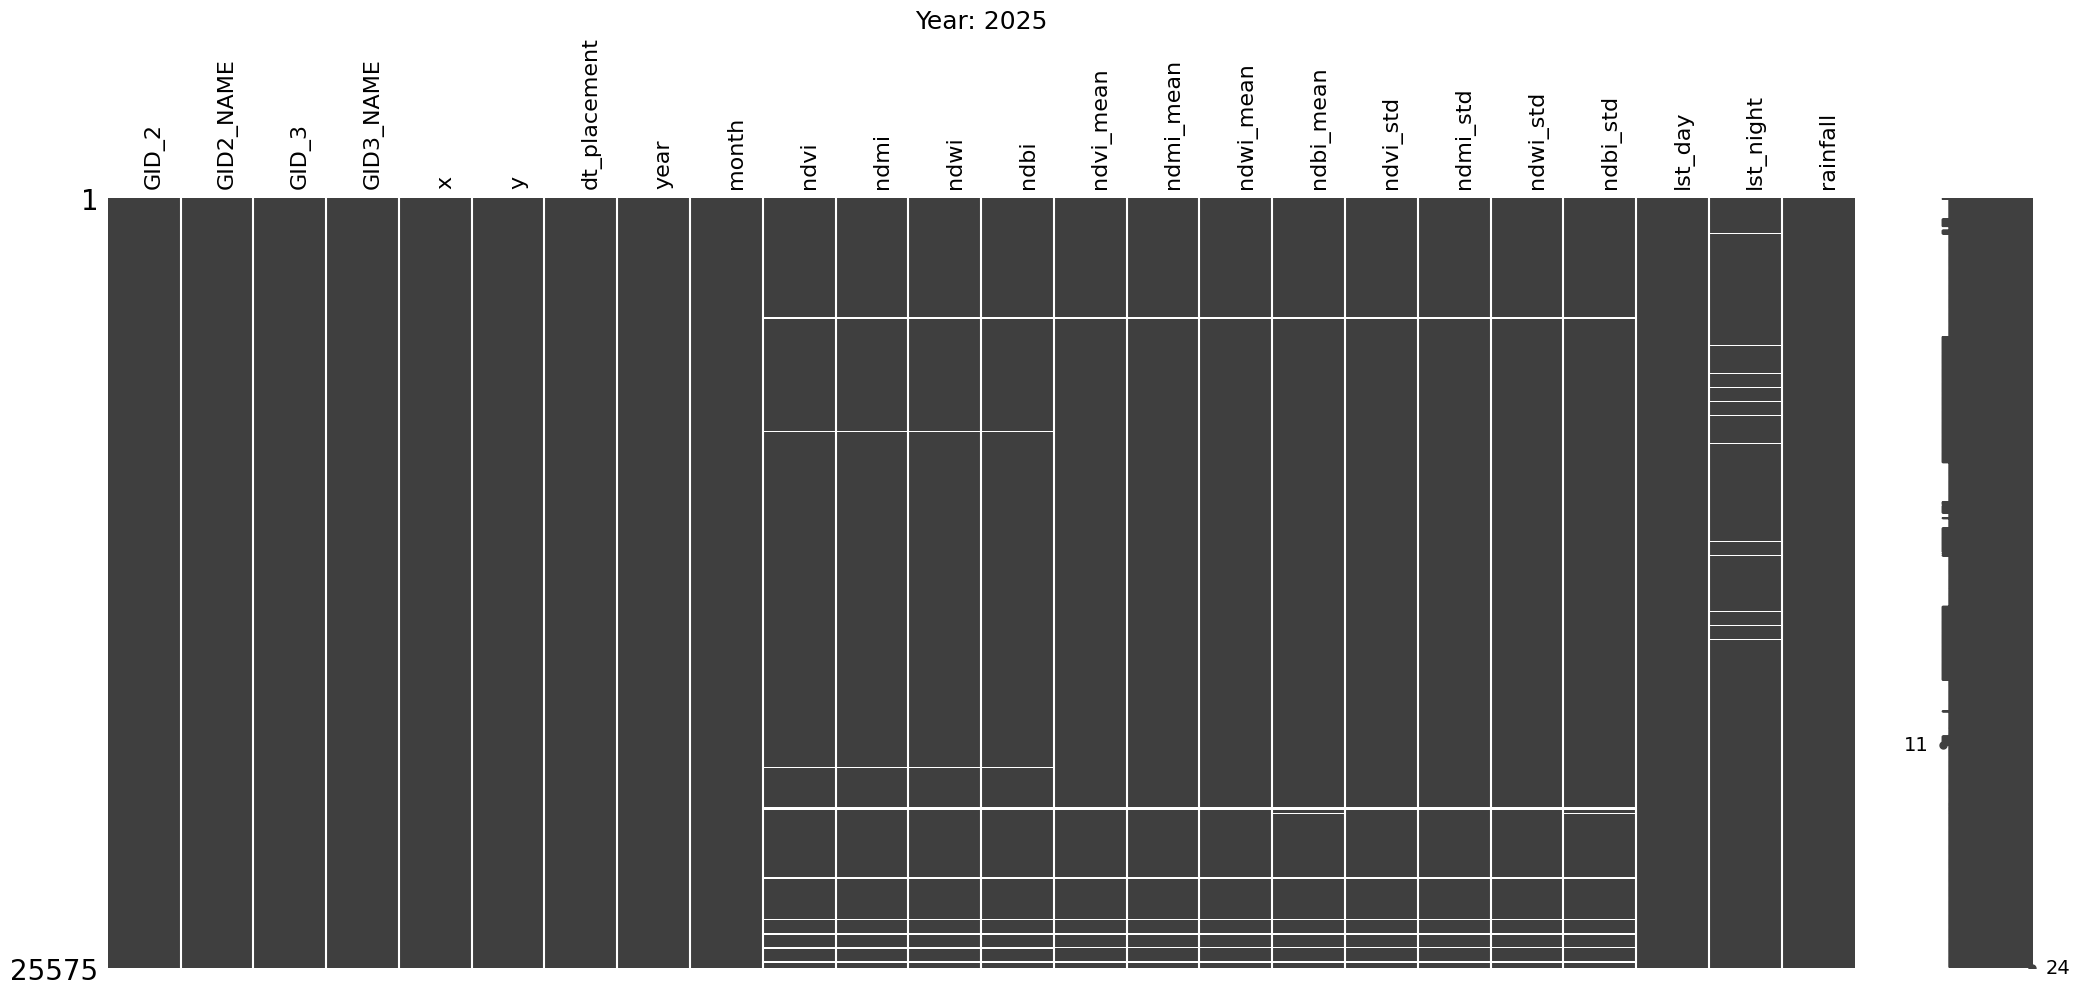

In [17]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [72]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding='utf-8')

In [18]:
df2.to_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_GID3_{YEAR}_filled.csv', encoding='utf-8')